# Sentiment Analysis of Strava Reviews from Apple App Store


In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
df_reviews = pd.read_csv("data/strava_reviews.csv")
display(df_reviews.head(10), df_reviews.describe(), df_reviews.shape)

,review,rating,date
0,Awsomeeee,5,2026-04-05T20:48:27-07:00
1,Paid for a subscription and it never unlocked ...,1,2026-04-05T20:25:07-07:00
2,I was immediately charged $80 for what was sup...,1,2026-04-05T18:43:31-07:00
3,The majority of the app has turned into a sche...,1,2026-04-05T12:55:19-07:00
4,Love the app but I CANNOT STAND how much it bu...,3,2026-04-04T15:41:38-07:00
5,I connected my heart rate monitor to the app. ...,1,2026-04-04T11:20:49-07:00
6,freetrailfretrail freetrailfretrail freetrailf...,1,2026-04-04T07:27:25-07:00
7,Every year Strava takes away at least one feat...,1,2026-04-04T05:51:20-07:00
8,I’ve had Strava for years and loved it. It was...,1,2026-04-03T23:10:11-07:00
9,Longtime member of Strava and lately I don’t k...,5,2026-04-02T17:13:59-07:00


,rating
count,490.000000
mean,2.965306
std,1.750495
min,1.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,5.000000


(490, 3)

# Visualizing App Reviews

With 490 review samples, the bar plot below indicates a relatively balanced distribution of ratings, particularly between 1-star and 5-star reviews, suggesting the dataset contains a strong mix of negative and positive sentiment.

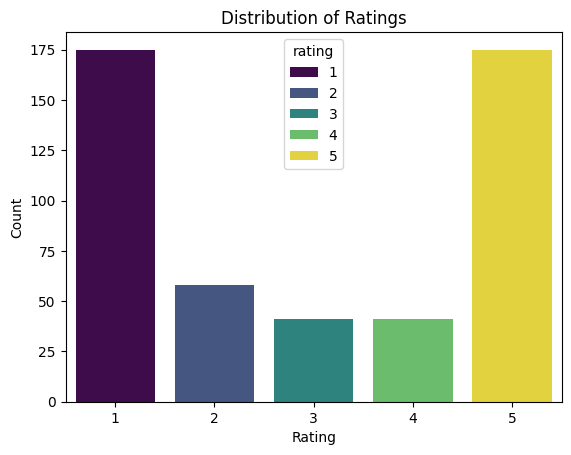

In [3]:
df_reviews_counts = df_reviews["rating"].value_counts().sort_index()
sns.barplot(x=df_reviews_counts.index, y=df_reviews_counts.values, hue=df_reviews_counts.index, palette="viridis")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The next visualization displays the average review word length by rating. The results indicate that lower-rated reviews (1–3 stars) generally contain more words on average than higher-rated reviews, suggesting that negative feedback tends to be more detailed and descriptive.

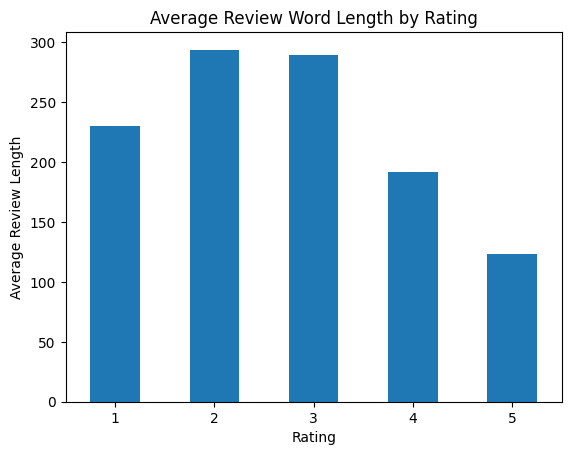

In [4]:
df_reviews["review_length"] = df_reviews["review"].str.len()

df_reviews.groupby("rating")["review_length"].mean().plot(kind="bar")
plt.title("Average Review Word Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Review Length")
plt.xticks(rotation=0)
plt.show()

This boxplot visualizes the distribution of review word lengths by rating. It highlights differences in median length, spread, and variability across ratings, while also showing outlier reviews that are unusually short or long compared to the rest of the data.

<Axes: xlabel='rating', ylabel='review_length'>

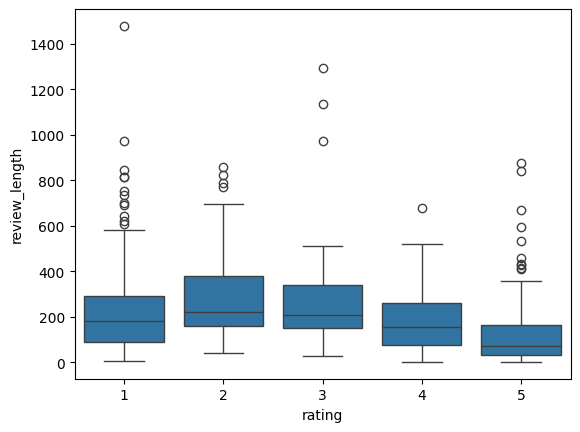

In [5]:
sns.boxplot(x="rating", y="review_length", data=df_reviews)

The visualization below shows the number of reviews over time which, highlights monthly trends in review volume. April shows a lower count compared to other months, which is expected since the dataset only includes data from the first week of the month.

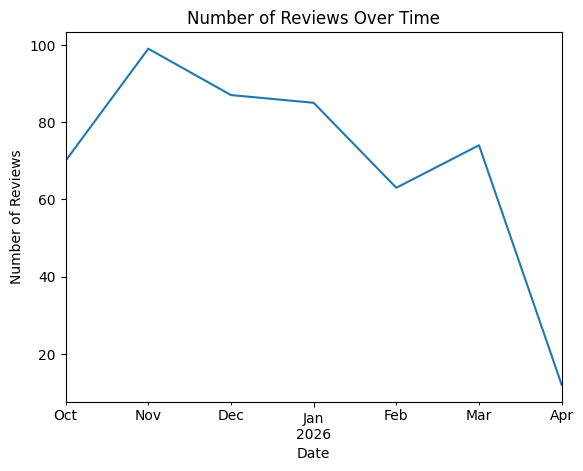

In [6]:
df_reviews["date"] = pd.to_datetime(df_reviews["date"])

df_reviews.groupby(df_reviews["date"].dt.to_period("M"))["rating"].count().plot()
plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

# Text Preprocessing

The core text preprocessing pipeline will be based on the following based on the paper _"The Role of Text Pre-processing in Sentiment Analysis" (2013 Hadi et al. )._ 

They emphasize the following stages:
1. Cleaning (noise removal)
2. Normalization
3. Tokenization
4. Stopword removal
5. Stemming or Lemmatization
6. Feature representation

## Step 1: Basic Cleaning

In [7]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df_reviews["clean_review"] = df_reviews["review"].astype(str).apply(clean_text)


## Step 2: Tokenization

In [8]:
import nltk
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

df_reviews["tokens"] = df_reviews["clean_review"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gclou\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step 3: Stopword Removal

In [9]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df_reviews["tokens_no_stop"] = df_reviews["tokens"].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gclou\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 4: Lemmatization

In [10]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df_reviews["lemmatized"] = df_reviews["tokens_no_stop"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gclou\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Step 5: Rebuild Cleaned Text

In [13]:
df_reviews["final_text"] = df_reviews["lemmatized"].apply(lambda x: " ".join(x))
df_reviews["clean_text"] = df_reviews["review"].str.lower()

print(f'Review before cleaning:\n{df_reviews["review"].iloc[1]}\n')
print(f'Review after cleaning:\n{df_reviews["final_text"].iloc[1]}\n')

Review before cleaning:
Paid for a subscription and it never unlocked any of the features. It did however keep offering me a trial. I started the trial, which also didn’t give me any of the features. Wish I had my money back.

Review after cleaning:
paid subscription never unlocked feature however keep offering trial started trial also didnt give feature wish money back



# Model Training
We will use TF-IDF (Term Frequency–Inverse Document Frequency) for building out features for our model. The model we will be using for sentiment analysis is `Logistic Regression `

Why TF-IDF?

It:

- downweights common words (“good”, “app”)
- upweights meaningful words (“crash”, “subscription”, “slow”)

## Step 1: Build TF-IDF features and targets

Targets:
- 1 = positive sentiment (4+ star ratings)
- 0 = negative/neutral (3 or below star ratings)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X = tfidf.fit_transform(df_reviews["clean_text"])
y = df_reviews["rating"].apply(lambda r: 1 if r >= 4 else 0)

# Step 2: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

0    1
1    0
2    0
3    0
4    0
Name: rating, dtype: int64


## Step 4: Train Model

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 5: Evaluate the Model

In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7959183673469388
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        61
           1       0.81      0.59      0.69        37

    accuracy                           0.80        98
   macro avg       0.80      0.76      0.77        98
weighted avg       0.80      0.80      0.79        98



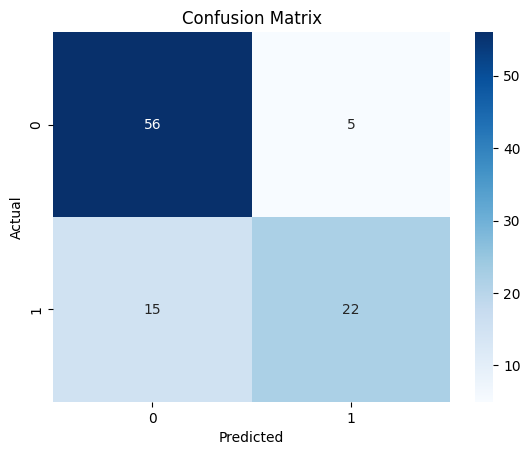

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Analysis

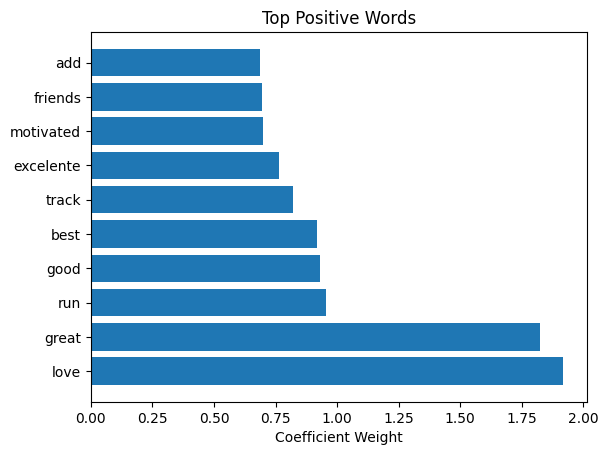

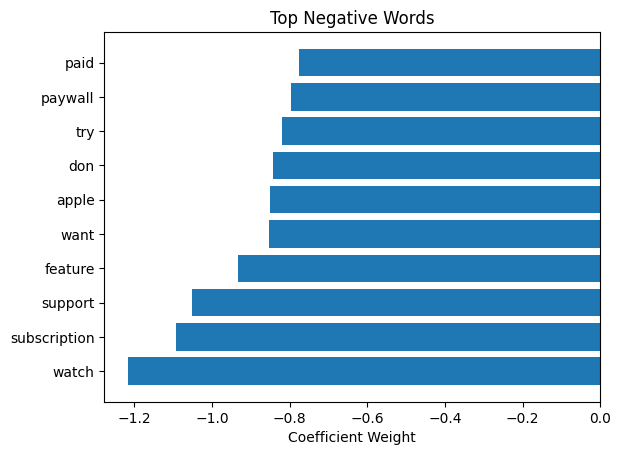

In [26]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]


feature_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

top_positive = feature_df.sort_values("weight", ascending=False).head(10)
top_negative = feature_df.sort_values("weight").head(10)

# Plotting the top positive and negative words
plt.barh(top_positive["word"], top_positive["weight"])
plt.title("Top Positive Words")
plt.xlabel("Coefficient Weight")
plt.show()

plt.barh(top_negative["word"], top_negative["weight"])
plt.title("Top Negative Words")
plt.xlabel("Coefficient Weight")
plt.show()

### Evaluation Metrics:

- **Accuracy:** 0.796 (~80%)

### Classification Report:

- Class 0 (Negative/Neutral):
  - Precision: 0.79
  - Recall: 0.92
  - F1-score: 0.85

- Class 1 (Positive):
  - Precision: 0.81
  - Recall: 0.59
  - F1-score: 0.69

---

## Key Insights

- The model achieves strong overall performance with approximately **80% accuracy**.
- It performs better at identifying **negative reviews**, with high recall (0.92), meaning most negative reviews are correctly detected.
- Performance on **positive reviews is weaker in recall (0.59)**, indicating that the model misses a portion of positive sentiments.
- This imbalance suggests that negative reviews contain stronger and more distinguishable linguistic signals (e.g., “crash”, “bug”, “slow”).

---

## Interpretation

The model demonstrates a slight bias toward predicting negative sentiment. This is likely due to:
- Stronger emotional language in negative reviews
- Imbalanced feature representation in text data
- Subtle or less explicit wording in positive reviews

Despite this, Logistic Regression with TF-IDF provides a strong and interpretable baseline for sentiment classification.

---

## Next Steps

- Try alternative models such as Naive Bayes or Linear SVM
- Improve recall for positive sentiment class
- Perform error analysis on misclassified reviews